In [4]:
# rm(list=ls())
library(limma)
library(parallel)
library(jsonlite)
library(UpSetR)
library(ggplot2)
library(parallel)

In [2]:
source("/workdir/sh2246/p_geneModelEvaluation/src//S00_basicFunction.R")

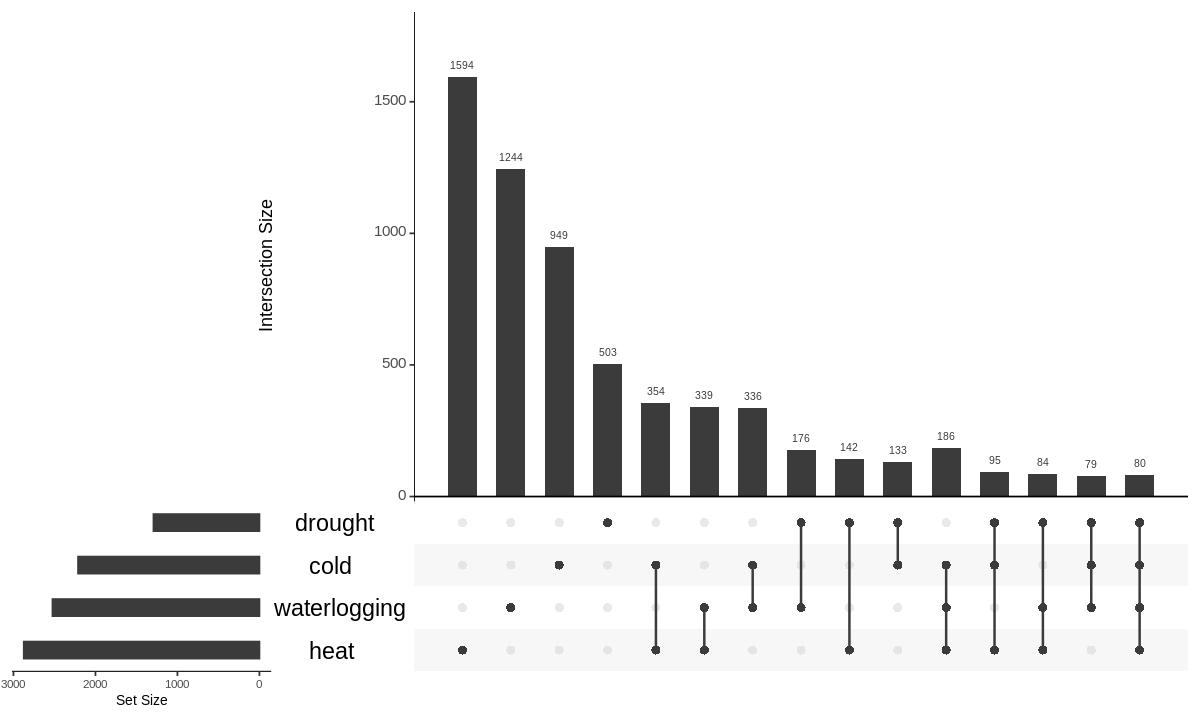

In [3]:
envResponsiveGenes = read_json("/workdir/sh2246/p_phyloGWAS_archived/output/candidateGenes/consistentEnvResponsiveGenes.json")

options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(envResponsiveGenes),text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [328]:
testResList = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/",
                                  pattern = "ASREML_res.txt",full.names = T,recursive = T),
                       read.table,header = T,mc.cores = 5)

In [329]:
head(testResList[[1]])

,OG,BIC_full,BIC_reduced,LR,p,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,OG0000164,81.35391,54.34152,6.795472,0.2363011,0.9742417,1.0623402,0.12304490,-0.03421844,0.03034984,-0.009984917,0.06265707,0.1389748,0.22994902,0.18743396,0.6661114,0.5854784
2,OG0000246,250.14478,222.41496,5.096505,0.4042165,0.8856714,0.9973314,-0.48332603,-0.03435158,-0.08024600,-0.032237099,-0.13401531,0.1461440,0.95881232,0.23352536,0.9998381,0.4089917
3,OG0000272,101.74457,79.53068,4.937490,0.2937718,0.9827458,1.1047425,NA,0.04436910,0.03040931,0.029616828,0.13344226,NA,0.67200974,0.04790418,0.3908854,0.4391742
4,OG0000306,141.64665,111.29778,3.341889,0.6474349,0.9596906,1.0459523,-0.07859281,-0.01691468,-0.01633829,-0.028741441,0.07348951,0.3040320,0.78964207,0.20215726,0.5040924,0.8120430
5,OG0000314,66.76012,36.44526,3.746863,0.5864058,0.9886402,1.0316347,-0.73827232,-0.06053689,0.01394081,0.020752887,0.05796836,0.6511577,0.23801881,0.70386713,0.4511972,0.4134707
6,OG0000315,86.89680,67.43937,7.680399,0.1040126,0.9801979,1.1073205,NA,-0.08220799,0.03718147,-0.009398524,0.06965929,NA,0.01374111,0.19050606,0.9156035,0.7579548


In [331]:
for (i in 1:5){
    testRes = testResList[[i]]
    topOG_list = unique(testRes$OG[testRes$p<0.001])
    testRes_permList = mclapply(list.files(paste0("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/envPC_",i,"/permulation/"),full.names = T),
                            read.table,header = T,mc.cores = 20)
    testRes_permMat = sapply(testRes_permList,function(x){
        tmp = x
        rownames(tmp) = tmp$OG
        tmp = tmp[topOG_list,]
        return(tmp[,5])
    })
    rownames(testRes_permMat) = topOG_list
    testRes_permMat = cbind(testRes$p[testRes$p < 0.001],
                                     testRes_permMat[topOG_list,])
    emp_p = apply(testRes_permMat,1,function(x) sum(x[-1]<x[1],na.rm = T))/1000
    testRes$emp_p = NA
    testRes$emp_p[testRes$p<.001] = emp_p
    write.table(testRes,paste0("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/envPC_",i,"/ASREML_res_empPadded.txt"),quote = F,sep = "\t",row.names = F)
}


In [332]:
testResList = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/",
                                  pattern = "ASREML_res_empPadded.txt",full.names = T,recursive = T),
                       read.table,header = T,mc.cores = 5)

In [523]:
set.seed(1234)
png("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5a1.png",width = 17.4,height = 8.7/2,units = "cm",res = 600,pointsize = 8)
layout(matrix(1:5,nrow = 1),widths = c(1.3,1,1,1,1))
for(i in 1:5){
    if (i ==1) par(mar= c(5,5,5,1))
    else par(mar= c(5,1,5,1))
    plot(sort(-log10(runif(0,1,n = nrow(testResList[[i]])))),
         sort(-log10(as.numeric(testResList[[i]]$p))),
         pch = 19,axes = F,col = ifelse(sort(-log10(as.numeric(testResList[[i]]$p)))>3,"orange",'black'),
         xlab = "",ylab = '',xlim = c(0,5),ylim = c(0,10),cex = .5,
         main = paste0("envPC",i),cex.main = 1.75)
    if(i ==1) {axis(2,cex.axis = 1.25); mtext("Observed",2,line = 3,cex = 1.25)}
    axis(1,cex.axis = 1.25)
    abline(a = 0, b= 1,col = "red")
    if (i == 3) mtext("Expected",1,line = 3,cex = 1.25)

}
dev.off()

pdf 
  2

In [333]:
sapply(testResList,function(x) sum(x$p<=1e-3))
sapply(testResList,function(x) sum(x$emp_p<=1e-3,na.rm = T))

[1] 275 204 211 162 180

[1] 160 109  68  36  30

In [334]:
mat = sapply(testResList,function(x) table(cut(na.omit(x$emp_p),c(0,.001,0.01,.05,1),include.lowest = T)))

In [335]:
library(ggplot2)
library(reshape2)
library(dplyr)

In [552]:
colnames(mat) = paste0(sapply(testResList,function(x) sum(x$p<=1e-3)))

# Melt to long format
df <- as.data.frame(mat) %>%
  mutate(Bin = rownames(.)) %>%
  melt(id.vars = "Bin", variable.name = "Column", value.name = "Count")

df$Bin = factor(df$Bin,levels = c("[0,0.001]","(0.001,0.01]","(0.01,0.05]","(0.05,1]"))
# Compute per-column totals and percentages
df <- df %>%
  group_by(Column) %>%
  mutate(Total = sum(Count),
         Prop = Count / Total) %>%
  ungroup()

# Now we assign a “width” aesthetic to make pies bigger for larger totals
# We pick a scaling: e.g. width = sqrt(Total) (so area ~ Total)
# (You can pick any transform you like)
df <- df %>%
  mutate(pie_width = Total)

# Plot
p1 = ggplot(df, aes(x = 1+(pie_width/2), y = Prop, fill = Bin, width = pie_width)) +
  geom_col(color = "grey",linewidth = .25) +
  coord_polar(theta = "y",start = 3.14/2) +
  scale_fill_manual(values = c("firebrick","darkorange","gold","grey"))+
  facet_wrap(~ Column,nrow = 1,scale = "fixed") +
  # add labels in slices
  geom_text(aes(label = Count),
            position = position_stack(vjust = c(0.75,.5,.5,.5)), size = 2,col = "white") +
  theme_void() +
  theme(legend.position = "bottom",strip.text.x.top = element_text(size = 12),
        legend.text = element_text(size = 6),legend.title = element_text(size = 8),
        legend.key.size = unit(.1,units = "inch"))+
  labs(fill = "Empirical\np-value")


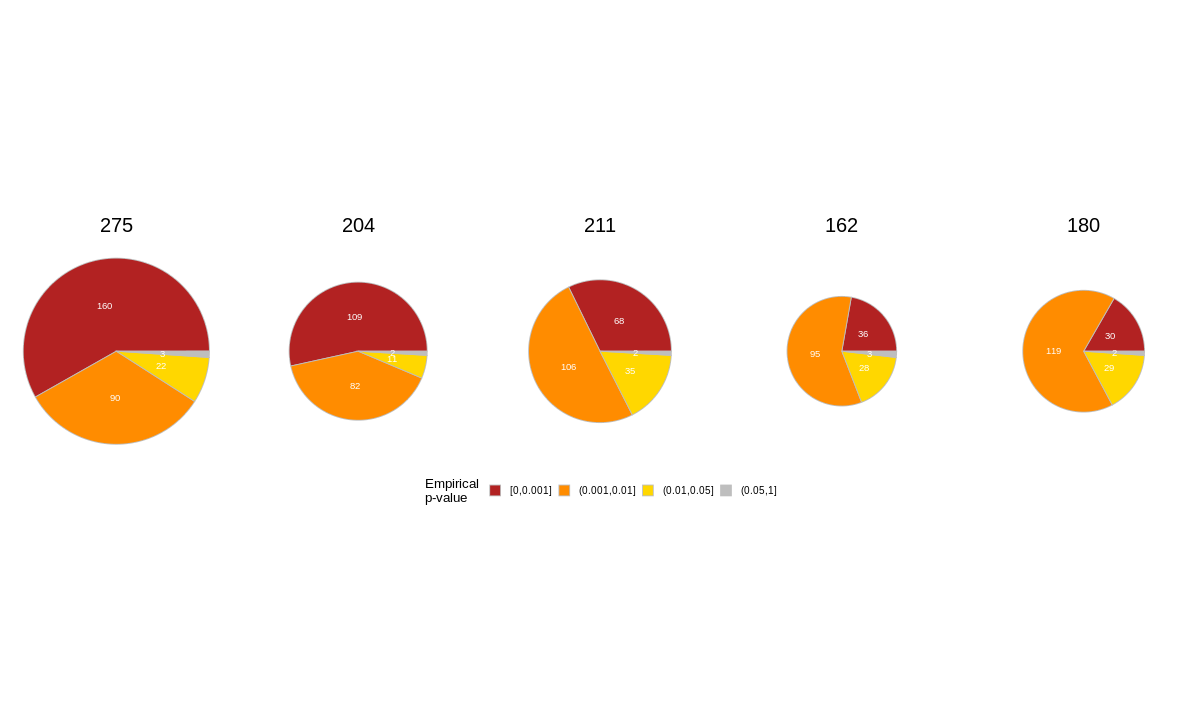

In [553]:
p1

In [554]:
ggsave("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5b.png",p1,device = "png",
       width = 16.4,height = 8.7/2,units = "cm",dpi = 600)

# data loading

In [704]:
metadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv",header = T)
rownames(metadata) = metadata$assemblyID

envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt")
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)


# enrichment analysis

In [153]:
candidateOGList = lapply(testResList, function(x) na.omit(x$OG[x$emp_p<=1e-3]))

In [154]:
oddsRatio = c()
pVal = c()
for(i in 1:5){
    tmpTest = lapply(envResponsiveGenes,function(x) {
        fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,x),alternative = "greater")
        })
    oddsRatio = rbind(oddsRatio,sapply(tmpTest,function(x) x$estimate))
    pVal = rbind(pVal,sapply(tmpTest,function(x) x$p.value))
}


In [155]:
oddsRatio
pVal

cold.odds ratio,heat.odds ratio,drought.odds ratio,waterlogging.odds ratio
1.2459182,0.9731892,1.790271,1.1512038
1.1205478,1.4500154,1.330375,1.4056970
2.3445826,1.0447860,1.427152,1.0825121
0.4849017,0.3577187,0.422890,0.4194476
0.9181080,0.9363522,1.053217,1.4252763


cold,heat,drought,waterlogging
0.20602725,0.58168006,0.0229551,0.3042498
0.39464397,0.08527999,0.2552218,0.1218833
0.00531536,0.50181193,0.2632937,0.4669063
0.91291402,0.97111286,0.9049475,0.9462554
0.64280328,0.62817977,0.5764456,0.3071740


In [348]:
colnames(oddsRatio) = colnames(pVal)
rownames(oddsRatio) = paste0("envPC",1:5)
rownames(pVal) = rownames(oddsRatio)

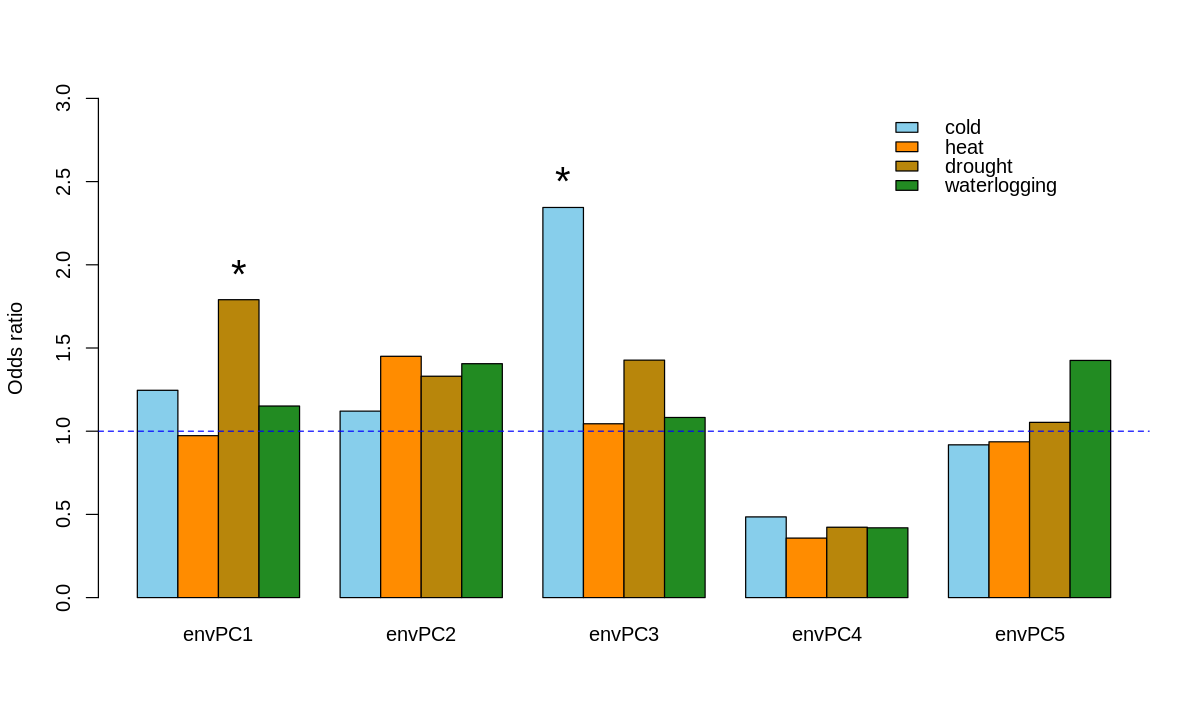

In [350]:
bp = barplot(t(oddsRatio),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio),ylab = "Odds ratio",args.legend = list(bty = 'n'))
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio),labels = ifelse(t(pVal)<.05,"*",""),pos = 3,cex = 2)

In [521]:
png("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5c.png",width = 17.4,height = 8.7*2/3,units = "cm",pointsize = 8,res = 600)
par(mar = c(1,3,1,1))
bp = barplot(t(oddsRatio),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio),ylab = "",args.legend = list(bty = 'n',cex = 1.2),cex.axis = 1)
mtext("Odds ratio",2,line = 2,cex = 1.2)
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio),labels = ifelse(t(pVal)<.01,"**",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.01&t(pVal)<.05,"*",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.05&t(pVal)<.1,".",""),pos = 3,cex = 2)

dev.off()

pdf 
  2

In [364]:
for(i in 1:5){
    print(fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,
                                 Reduce("intersect",envResponsiveGenes[c(2,4)])),alternative = "greater"))
}


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.7733
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.2542356       Inf
sample estimates:
odds ratio 
 0.7553084 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.1643
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.7096737       Inf
sample estimates:
odds ratio 
  1.669776 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 1
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
   0 Inf
sample estimates:
odds ratio 
         0 


	Fisher's Exact Test for Count D

In [600]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS_archived/output/OGToPv_mapping_v2.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS_archived/output/OGToZm_mapping_v2.txt")

colnames(mappingFile) = c("PvID","OG")
colnames(mappingFile2) = c("ZmID","OG")

mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)


In [601]:
mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],2]

[1] "Pavag02G236200.1" "Pavag02G004100.1" "Pavag04G015600.1"
  [4] "Pavag06G162300.1" "Pavag05G226600.1" "Pavag01G354300.1"
  [7] "Pavag03G319400.1" "Pavag04G187600.1" "Pavag09G178700.1"
 [10] "Pavag02G237000.1" "Pavag10G264300.1" "Pavag06G273800.1"
 [13] "Pavag01G146000.1" "Pavag01G149600.1" "Pavag04G003700.1"
 [16] "Pavag01G396400.1" "Pavag05G092000.1" "Pavag06G191000.1"
 [19] "Pavag10G271100.1" "Pavag09G221000.1" "Pavag03G187200.1"
 [22] "Pavag04G195600.1" "Pavag01G500100.1" "Pavag01G357400.1"
 [25] "Pavag01G216100.1" "Pavag03G078700.5" "Pavag08G107300.1"
 [28] "Pavag07G055900.1" "Pavag05G191500.1" "Pavag03G070300.1"
 [31] "Pavag01G020200.2" "Pavag02G367700.1" "Pavag02G232000.2"
 [34] "Pavag03G074800.1" "Pavag07G086100.1" "Pavag08G123200.1"
 [37] "Pavag04G064500.1" "Pavag06G058500.4" "Pavag08G026200.1"
 [40] "Pavag06G109900.1" "Pavag04G003000.1" "Pavag02G316700.1"
 [43] "Pavag05G001200.3" "Pavag09G216200.1" "Pavag03G038500.2"
 [46] "Pavag10G239900.1" "Pavag03G354200.1" "Pavag03G194100.1"
 [49] "Pavag03G020100.1" "Pavag01G392300.1" "Pavag03G318500.1"
 [52] "Pavag03G112600.1" "Pavag03G373500.1" "Pavag07G046200.1"
 [55] "Pavag07G024300.1" "Pavag01G019500.1" "Pavag09G251900.1"
 [58] "Pavag10G235100.1" "Pavag10G166000.3" "Pavag03G366500.1"
 [61] "Pavag03G289000.1" "Pavag06G114600.1" "Pavag01G354100.1"
 [64] "Pavag10G243900.2" "Pavag03G129400.1" "Pavag07G152600.1"
 [67] "Pavag01G319000.1" "Pavag04G180800.1" "Pavag04G278600.1"
 [70] "Pavag02G255800.1" "Pavag09G024700.2" "Pavag06G090100.1"
 [73] "Pavag01G180600.1" "Pavag01G088300.3" "Pavag04G073000.1"
 [76] "Pavag04G145200.1" "Pavag04G188200.1" "Pavag02G227600.1"
 [79] "Pavag07G094000.2" "Pavag04G236400.2" "Pavag02G357900.1"
 [82] "Pavag03G166200.1" "Pavag07G185700.1" "Pavag06G024000.1"
 [85] "Pavag06G287900.1" "Pavag04G008900.2" "Pavag04G164400.2"
 [88] "Pavag08G149300.1" "Pavag10G028700.2" "Pavag03G168600.1"
 [91] "Pavag03G047900.1" "Pavag01G195500.1" "Pavag06G068600.1"
 [94] "Pavag02G328200.1" "Pavag04G318200.1" "Pavag10G277600.1"
 [97] "Pavag10G095000.1" "Pavag06G220800.3" "Pavag05G136900.2"
[100] "Pavag01G275300.1" "Pavag02G373800.1" "Pavag02G325600.2"
[103] "Pavag03G149500.1" "Pavag03G010700.1" "Pavag01G171100.1"
[106] "Pavag03G161000.1" "Pavag04G074000.1" "Pavag02G363700.1"
[109] "Pavag02G313800.1" "Pavag05G015400.1" "Pavag10G054000.1"
[112] "Pavag03G221600.1" "Pavag05G159300.1" "Pavag10G034600.1"
[115] "Pavag01G099600.1" "Pavag06G152600.1" "Pavag06G262400.1"
[118] "Pavag03G003400.1" "Pavag01G175200.1" "Pavag01G469800.1"
[121] "Pavag04G306900.1" "Pavag02G288800.1" "Pavag04G141900.1"
[124] "Pavag06G094700.1" "Pavag06G277900.1" "Pavag02G114100.2"
[127] "Pavag10G037000.1" "Pavag08G087500.1" "Pavag03G175500.1"
[130] "Pavag04G331900.1" "Pavag02G091200.1" "Pavag03G219800.1"
[133] "Pavag06G139500.1" "Pavag01G185400.1" "Pavag05G180000.1"
[136] "Pavag05G173700.1" "Pavag04G289700.1" "Pavag02G358700.1"
[139] "Pavag04G231400.1" "Pavag01G310200.1" "Pavag07G141900.1"
[142] "Pavag09G135300.1" "Pavag02G266600.1" "PavagK276600.1"  
[145] "Pavag09G089200.1" "Pavag10G176500.1" "Pavag02G154300.1"
[148] "Pavag03G419400.7" "Pavag09G234900.1" "PavagK123000.1"  
[151] "Pavag07G083200.1" "Pavag03G189500.1" "Pavag03G359700.4"
[154] "Pavag01G106600.1" "Pavag10G215900.1" "Pavag02G087500.1"
[157] "Pavag03G130000.1"

In [603]:
library(topGO)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: graph

Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Bi

In [631]:
GODB <- readMappings("/workdir/sh2246/p_phyloGWAS/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
background = intersect(names(GODB),substr(mappingFileMerged$ZmID,1,15))
# background = names(GODB)

tmp=factor(as.integer(background%in%substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],3],1,15)))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "elim", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                      orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                      topNodes=length(resTopGO.classic@score),numChar=100)



Building most specific GOs .....

	( 3729 GO terms found. )


Build GO DAG topology ..........

	( 5296 GO terms and 11198 relations. )


Annotating nodes ...............

	( 12805 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 15:	2 nodes to be scored	(0 eliminated genes)


	 Level 14:	5 nodes to be scored	(0 eliminated genes)


	 Level 13:	9 nodes to be scored	(0 eliminated genes)


	 Level 12:	17 nodes to be scored	(0 eliminated genes)


	 Level 11:	27 nodes to be scored	(0 eliminated genes)


	 Level 10:	53 nodes to be scored	(0 eliminated genes)


	 Level 9:	96 nodes to be scored	(36 eliminated genes)


	 Level 8:	103 nodes to be scored	(133 eliminated genes)


	 Level 7:	136 nodes to be scored	(133 eliminated genes)


	 Lev

In [636]:
GO_res_table$foldER = GO_res_table$Significant/GO_res_table$Expected

In [672]:
topGOTab = subset(GO_res_table,Fisher.weight01<0.05 & Significant >1&foldER>5)
topGOTab = tail(topGOTab[order(topGOTab$foldER),],10)

In [693]:
topGOTab

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>
23,GO:0009694,jasmonic acid metabolic process,30,2,0.28,39,0.0314,0.0314,7.142857
19,GO:0010224,response to UV-B,28,2,0.26,35,0.0277,0.0277,7.692308
15,GO:0051983,regulation of chromosome segregation,24,2,0.22,27,0.0207,0.0207,9.090909
14,GO:0007264,small GTPase mediated signal transduction,22,2,0.20,26,0.0175,0.0175,10.000000
3,GO:0006890,"retrograde vesicle-mediated transport, Golgi to endoplasmic reticulum",30,3,0.28,5,0.0026,0.0026,10.714286
1,GO:0090376,seed trichome differentiation,25,3,0.23,2,0.0016,0.0016,13.043478
10,GO:0010167,response to nitrate,16,2,0.15,20,0.0094,0.0094,13.333333
9,GO:0010337,regulation of salicylic acid metabolic process,15,2,0.14,18,0.0083,0.0083,14.285714
5,GO:0035246,peptidyl-arginine N-methylation,11,2,0.10,9,0.0045,0.0045,20.000000


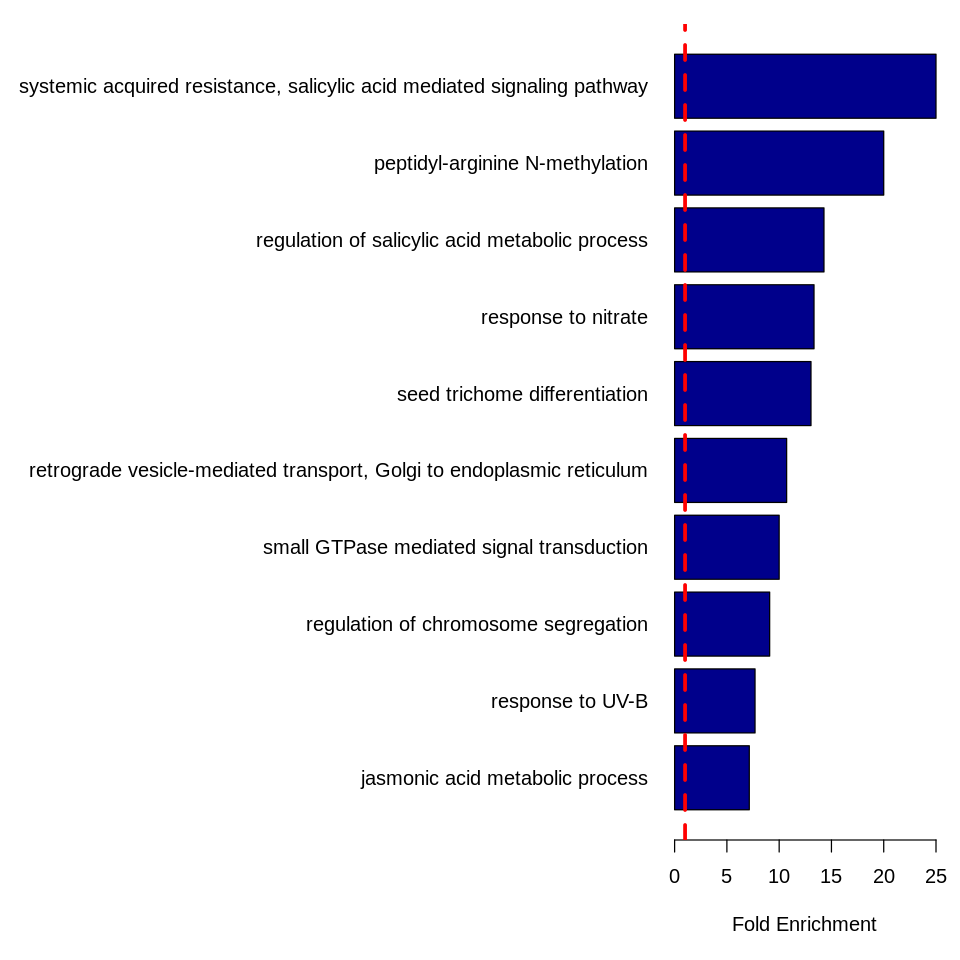

In [680]:
options(repr.plot.width=8, repr.plot.height=8)
par(mar= c(5,28,1,1))
bp = barplot(topGOTab$foldER,horiz = T,names.arg = topGOTab$Term,las = 1,xlab = "Fold Enrichment",col = "darkblue")
abline(v = 1, col = "red",lty = 2,lwd = 3)
# text(topGOTab$foldER,bp,topGOTab$Significant,col ="white",pos = 2)

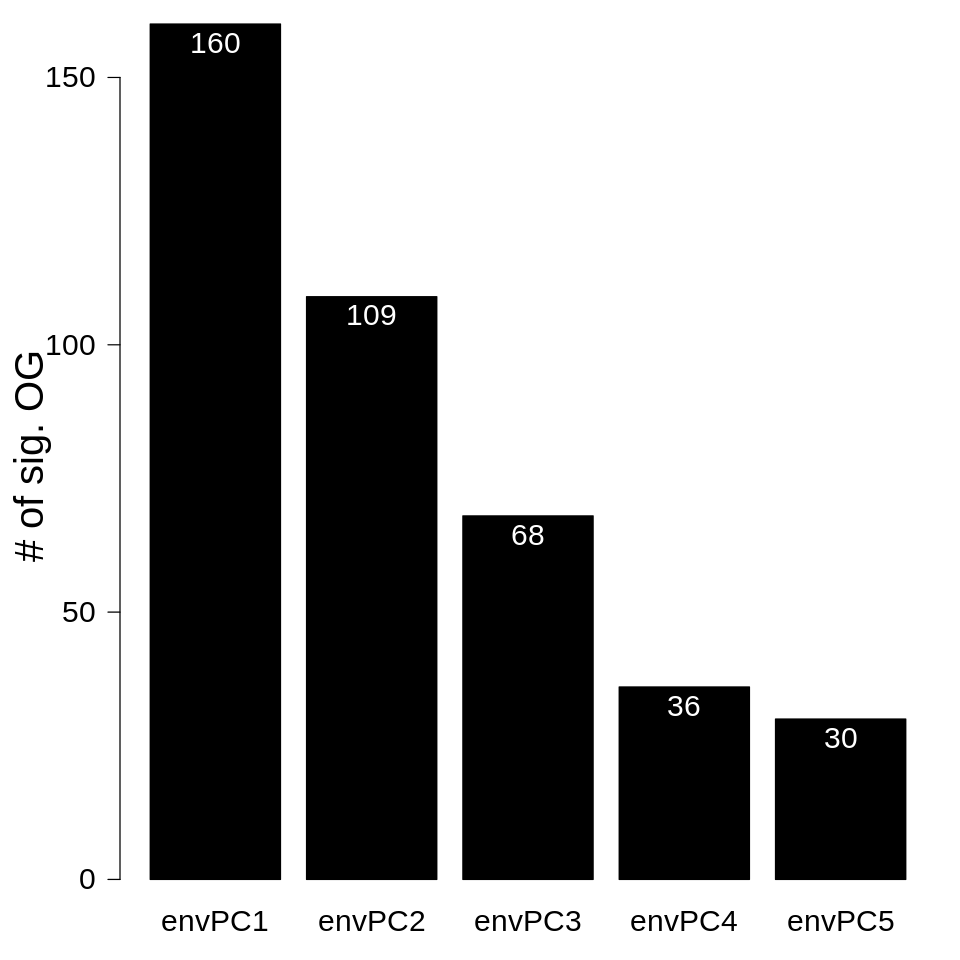

In [692]:
par(mar= c(3,5,1,1))
bp = barplot(sapply(candidateOGList,length),las = 1, names.arg = paste0("envPC",1:5),
             ylab = "# of sig. OG",col = "black",cex.names = 1.5,cex.axis = 1.5,cex.lab = 2)
text(bp,sapply(candidateOGList,length),sapply(candidateOGList,length),pos = 1,col = "white",cex = 1.5)

# candidate gene identification & visualization

In [ ]:
# Zm00001eb317090 = OG0011444 = bk4; nearly all lost in the pooideae ; POM1 (POM-POM1) (Primary Symbol), ELP (ECTOPIC DEPOSITION OF LIGNIN IN PITH), ERH1, CTL1 (CHITINASE-LIKE PROTEIN 1), ERH1 (ECTOPIC ROOT HAIR 1), ERH2 (ECTOPIC ROOT HAIR 2), ELP1 (ECTOPIC DEPOSITION OF LIGNIN IN PITH 1), HOT2 (SENSITIVE TO HOT TEMPERATURES 2), ATCTL1 
# Zm00001eb125120 = OG0006053 = SARD1; cold inducible; pattern not clear

In [851]:
intersect(substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],3],1,15),
          genesInTerm(tgd1,"GO:0006890")[[1]])

[1] "Zm00001eb227430" "Zm00001eb272330" "Zm00001eb359130"

In [868]:
subset(mappingFileMerged,substr(ZmID,1,15)%in%"Zm00001eb359130")

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
15894,OG0017435,Pavag08G087500.1,Zm00001eb359130_T002


In [958]:
ovlp1 = intersect(unlist(candidateOGList),envResponsiveGenes$drought)
ovlp2 = subset(mappingFileMerged,substr(ZmID,1,15)%in%intersect(substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],3],1,15),
          unlist(genesInTerm(tgd1,topGOTab$GO.ID))))[,1]

In [963]:
subset(mappingFileMerged,OG%in%intersect(ovlp1,ovlp2))

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
736,OG0001226,Pavag04G015600.1,Zm00001eb230300_T001
5077,OG0006053,Pavag03G074800.1,Zm00001eb125120_T002


In [1088]:
sapply(envResponsiveGenes,function(x) any(x%in%"OG0006053"))

cold         heat      drought waterlogging 
        TRUE        FALSE         TRUE         TRUE

In [1089]:
subset(testResList[[2]],OG%in%"OG0006053")

,OG,BIC_full,BIC_reduced,LR,p,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,emp_p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4454,OG0006053,482.9766,458.5046,2.301281,0.6805358,0.8504292,0.9541966,NA,-0.0267394,0.02879337,-0.005465337,0.3754222,NA,0.04943624,0.9687636,0.9643096,0.1700565,NA


In [808]:
myX = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/functionPredictionPerOG_20251023.txt",data.table = F)
rownames(myX) = myX[,1]
myX = as.matrix(myX[,-1])

In [1108]:
qnorm(0.99,0,1)

[1] 2.326348

In [1119]:
subX = myX[,grep("OG0006053",colnames(myX))]
binX = subX
binX[,1:2] = subX[,1:2] < (-1.64)
binX[,c(3,5)] = subX[,c(3,5)] == 0
binX[,4] = subX[,4] > 1.64

In [1120]:
subset(metadata[names(which(rowSums(binX)>0)),],subtribe!="")[,c(3,15)]
subX[subset(metadata[names(which(rowSums(binX)>0)),],subtribe!="")[,1],]
envDf[subset(metadata[names(which(rowSums(binX)>0)),],subtribe!="")[,1],c(1,287)]

,correctSpecies,subtribe
,<chr>,<chr>
AN20TSCR000212,Hyparrhenia rufa,Andropogoninae
AN21TNTL0091,Sorghastrum fuscescens,Apludinae
AN21TNTL0309,Ischaemum timorense,Ischaeminae
AN21TNTL0368,Zea perennis,Tripsacinae
AN21TSTL0009,Saccharum baldwinii,Saccharinae
AN21TSTL0212,Saccharum fallax,Saccharinae
AN21TSTL0272,Cymbopogon distans,Anthistiriinae
AN22TNTL124,Ischaemum rangacharianum,Ischaeminae
AN22TNTL128,Dichanthium caricosum,Anthistiriinae


,ESM2_OG0006053,PlantCad_OG0006053,PMS_OG0006053,omega_OG0006053,PAV_OG0006053
AN20TSCR000212,-1.65253675,-0.29128944,1,0.12331899,1
AN21TNTL0091,-2.14328466,0.20233605,0,0.40218031,1
AN21TNTL0309,-1.91880827,-1.50282254,1,-2.72075802,1
AN21TNTL0368,0.22493015,-1.33515349,1,2.30661328,1
AN21TSTL0009,-0.35323787,-0.85634926,0,0.29541133,1
AN21TSTL0212,0.03651608,-2.59520830,1,-1.61116857,1
AN21TSTL0272,-3.85016888,-1.70033674,0,-1.59588652,1
AN22TNTL124,-4.85639827,-0.66692384,1,-3.28889877,1
AN22TNTL128,-0.44547741,-1.73964177,1,0.66024101,1
ASM151433v2,-0.70897561,-0.83721072,0,0.17050812,1


,assemblyID,envPC_1
,<fct>,<dbl>
AN20TSCR000212,AN20TSCR000212,0.76031
AN21TNTL0091,AN21TNTL0091,-0.08836
AN21TNTL0309,AN21TNTL0309,1.32610
AN21TNTL0368,AN21TNTL0368,-0.30433
AN21TSTL0009,AN21TSTL0009,-0.35802
AN21TSTL0212,AN21TSTL0212,0.49834
AN21TSTL0272,AN21TSTL0272,-1.27167
AN22TNTL124,AN22TNTL124,2.10561
AN22TNTL128,AN22TNTL128,0.83622


In [1121]:
subX[grep("Zm-B73",rownames(subX)),]

ESM2_OG0006053 PlantCad_OG0006053      PMS_OG0006053    omega_OG0006053 
         0.5373041          0.3092855          1.0000000          1.0642817 
     PAV_OG0006053 
         1.0000000

In [1122]:
pDf = data.frame(envPC =c(envDf[rownames(myX),]$envPC_1,envDf[rownames(myX),]$envPC_2),
                 envPC_class = rep(c("envPC_1","envPC_2"),each = nrow(myX)),
                 LoF = rep(as.factor(rowSums(binX)>0),2),
                 subtribe = rep(metadata[rownames(myX),]$subtribe,2))

In [1123]:
table(pDf$LoF)/2
table(pDf$LoF,pDf$subtribe)/2


FALSE  TRUE 
  649    37 

       
            Alopecurinae Andropogoninae Anthephorinae Anthistiriinae Apludinae
  FALSE  34            2            145             2             76        21
  TRUE    4            0              4             0              3         1
       
        Arthraxoninae Arthrostylidiinae Arundinariinae Aveninae Bambusinae
  FALSE            10                 1             10       23          4
  TRUE              0                 0              0        1          0
       
        Boivinellinae Brachypodiinae Brominae Cenchrinae Chionachninae
  FALSE             7              7        2         11             2
  TRUE              0              0        0          0             0
       
        Chrysopogoninae Coleanthinae Dactylidinae Dichantheliinae Eleusininae
  FALSE              13            1            2               1           8
  TRUE                0            0            0               0           2
       
        Eragrostidinae Germainiinae Guaduinae Horde

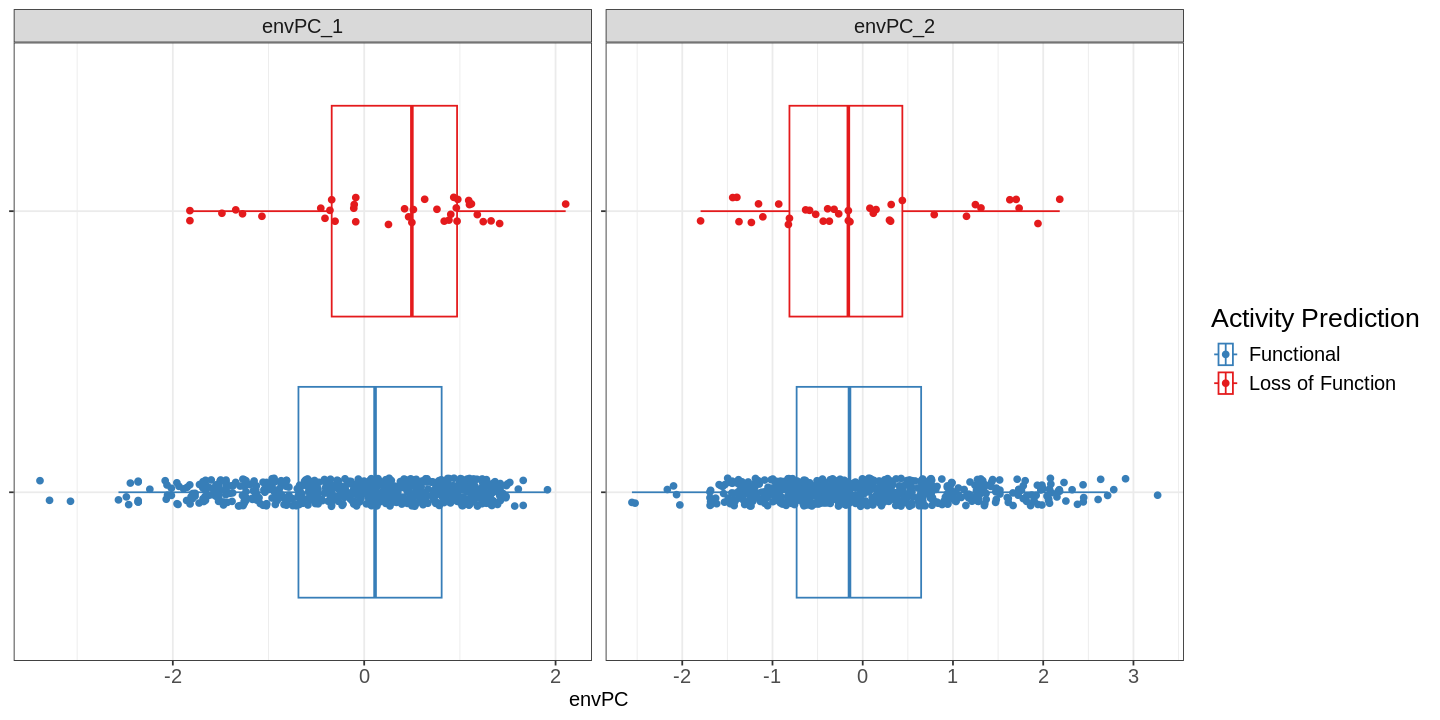

In [1124]:
# hist(pDf$envPC1[pDf$LoF=="FALSE"],col = alpha("red",.5),freq = F,breaks = seq(-3.5,3,.2),ylim = c(0,1))
# hist(pDf$envPC1[pDf$LoF=="TRUE"],col = alpha("blue",.5),add = T,freq = F,breaks = seq(-3.5,3,.2))
options(repr.plot.width=12, repr.plot.height=6)
ggplot(pDf,aes(y=LoF,x=envPC,col = LoF))+
    geom_boxplot(outlier.shape = NA,fill=NA)+
    geom_jitter(aes(color = LoF),position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.75))+
    facet_wrap(~envPC_class,nrow = 1,scales = "free")+
    scale_y_discrete(labels = c(
      "TRUE" = "Loss of Function",
      "FALSE" = "Functional"),
    name = "Activity Prediction"  # Legend title
  )+
    scale_color_manual(
    values = c(
      "TRUE" = "#E41A1C",   # red
      "FALSE" = "#377EB8"  # blue
      ),
    labels = c(
      "TRUE" = "Loss of Function",
      "FALSE" = "Functional"),
    name = "Activity Prediction"  # Legend title
  ) +
    theme_bw()+
    theme(axis.text.y = element_blank(),axis.text.x = element_text(size = 12),
          strip.text.x.top = element_text(size = 12),
          axis.title.y = element_blank(),axis.title.x = element_text(size = 12),
          legend.title = element_text(size = 16),legend.text = element_text(size = 12))

In [1125]:
subIdx = apply(table(metadata[rownames(myX),]$subtribe,rowSums(binX)>0),1,function(x) sum(x)>10&all(x>=2))
subIdx
pDf_sub = pDf[pDf$subtribe %in% names(which(subIdx[-1])),]

Alopecurinae    Andropogoninae     Anthephorinae 
             TRUE             FALSE              TRUE             FALSE 
   Anthistiriinae         Apludinae     Arthraxoninae Arthrostylidiinae 
             TRUE             FALSE             FALSE             FALSE 
   Arundinariinae          Aveninae        Bambusinae     Boivinellinae 
            FALSE             FALSE             FALSE             FALSE 
   Brachypodiinae          Brominae        Cenchrinae     Chionachninae 
            FALSE             FALSE             FALSE             FALSE 
  Chrysopogoninae      Coleanthinae      Dactylidinae   Dichantheliinae 
            FALSE             FALSE             FALSE             FALSE 
      Eleusininae    Eragrostidinae      Germainiinae         Guaduinae 
            FALSE             FALSE             FALSE             FALSE 
        Hordeinae    Hsuehochloinae       Ischaeminae          Loliinae 
            FALSE             FALSE              TRUE             FALSE 
      Melinidinae      Melocanninae         Molininae          Olyrinae 
            FALSE             FALSE             FALSE             FALSE 
      Orcuttiinae          Orininae          Oryzinae         Panicinae 
            FALSE             FALSE              TRUE             FALSE 
       Paspalinae            Poinae    Ratzeburgiinae      Rhytachninae 
            FALSE             FALSE             FALSE             FALSE 
   Rottboelliinae       Saccharinae         Sorghinae      Sporobolinae 
            FALSE              TRUE             FALSE             FALSE 
     Tripogoninae       Tripsacinae     Triraphidinae        Triticinae 
            FALSE             FALSE             FALSE             FALSE 
       Zizaniinae         Zoysiinae 
            FALSE             FALSE

In [1126]:
pDf_plot <- pDf_sub %>%
  mutate(subtribe = as.character(subtribe)) %>%
  bind_rows(
    pDf_sub %>% mutate(subtribe = "All")  # pooled copy
  )

# 2️⃣ Make sure the "All" row appears at the bottom (or top)
pDf_plot$subtribe <- factor(
  pDf_plot$subtribe,
  levels = c(sort(unique(pDf_sub$subtribe)), "All")   # "All" at bottom
  #or prepend "All" if you want it on top:
#   levels = c("All", sort(unique(pDf_sub$subtribe)))
)

In [1127]:
options(repr.plot.width=12, repr.plot.height=6)
p1 = ggplot(pDf_plot,aes(y=subtribe,x=envPC,col = LoF))+
    geom_boxplot(outlier.shape = NA,fill=NA)+
    geom_jitter(aes(color = LoF),position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.75),alpha = .5)+
    facet_wrap(~envPC_class)+
    scale_color_manual(
    values = c(
      "TRUE" = "#E41A1C",   # red
      "FALSE" = "#377EB8"  # blue
      ),
    labels = c(
      "TRUE" = "Loss of Function",
      "FALSE" = "Functional"),
    name = "Activity Prediction"  # Legend title
  ) +
    theme_bw()+
    theme(axis.text.y = element_text(size = 12),axis.text.x = element_text(size = 12),
          strip.text.x.top = element_text(size = 12),
          axis.title.y = element_text(size = 12),axis.title.x = element_text(size = 12),
          legend.title = element_text(size = 16),legend.text = element_text(size = 12))

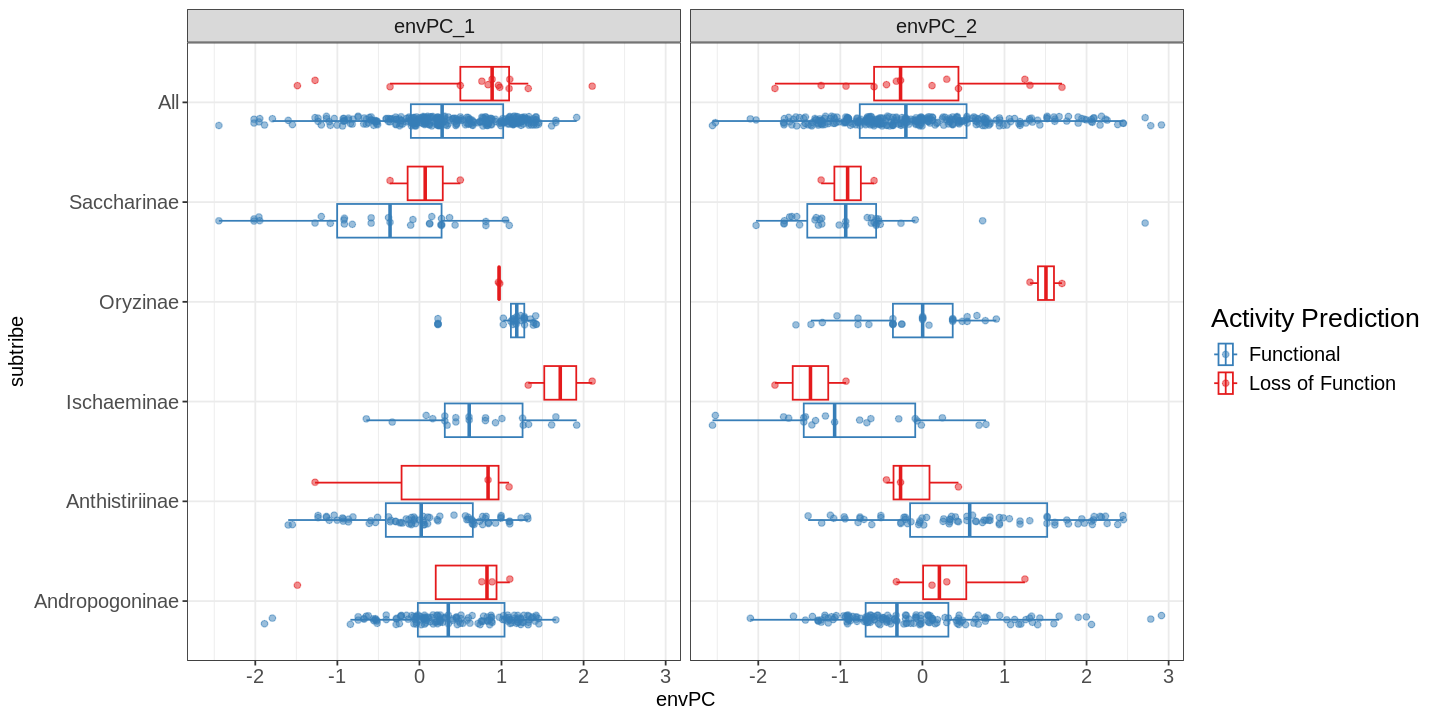

In [1128]:
p1

In [ ]:
ggsave

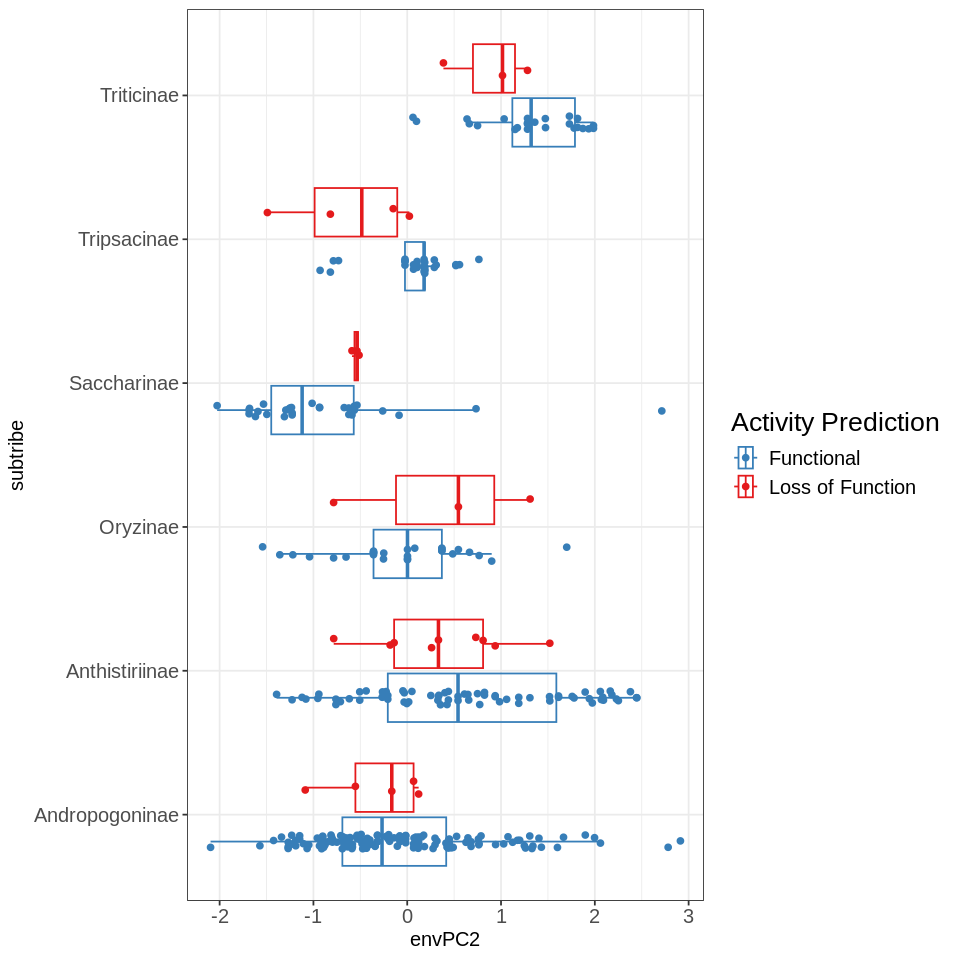

In [905]:
ggplot(pDf_sub,aes(y=subtribe,x=envPC2,col = LoF))+
    geom_boxplot(outlier.shape = NA,fill=NA)+
    geom_jitter(aes(color = LoF),position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.75))+
    scale_color_manual(
    values = c(
      "TRUE" = "#E41A1C",   # red
      "FALSE" = "#377EB8"  # blue
      ),
    labels = c(
      "TRUE" = "Loss of Function",
      "FALSE" = "Functional"),
    name = "Activity Prediction"  # Legend title
  ) +
    theme_bw()+
    theme(axis.text.y = element_text(size = 12),axis.text.x = element_text(size = 12),
          axis.title.y = element_text(size = 12),axis.title.x = element_text(size = 12),
          legend.title = element_text(size = 16),legend.text = element_text(size = 12))